# 07 - Machine Learning Classifiers (Higher-Accuracy Setup)

Train tuned tree-based classifiers (Random Forest and Extra Trees) on stronger intraday-structure features and compare full evaluation metrics.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
import config

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              RocCurveDisplay)

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({'figure.dpi': config.FIG_DPI})

## 1. Load Data & Split

In [2]:
df = pd.read_csv(
    config.PROCESSED_DATA_CSV,
    index_col='Date', parse_dates=True
)

# Intraday structure features (stronger signal than technical-only set).
df['Range'] = (df['High'] - df['Low']) / df['Open']
df['High_to_Open'] = (df['High'] - df['Open']) / df['Open']
df['Low_to_Open'] = (df['Low'] - df['Open']) / df['Open']
df['Mid_to_Open'] = ((df['High'] + df['Low']) / 2 - df['Open']) / df['Open']
df['Open_to_prev_close'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)
df = df.dropna().copy()

FEATURES = ['High_to_Open', 'Low_to_Open', 'Open_to_prev_close', 'Range', 'Mid_to_Open']
X = df[FEATURES].values
y = df[config.TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE,
    shuffle=False, random_state=config.RANDOM_STATE
)

print(f'Asset: {config.ASSET_NAME} ({config.ASSET_TICKER})')
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Asset: S&P 500 (^GSPC)
Train: (3113, 5)  Test: (779, 5)


## 2. Random Forest

In [3]:
rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=8,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=config.RANDOM_STATE,
    n_jobs=-1,
    bootstrap=True,
    criterion='gini',
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

metrics_rf = {
    'Model':     'Random Forest',
    'Accuracy':  accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall':    recall_score(y_test, y_pred_rf),
    'F1':        f1_score(y_test, y_pred_rf),
    'ROC-AUC':   roc_auc_score(y_test, y_prob_rf),
}
for k, v in metrics_rf.items():
    print(f'  {k:<12}: {v}' if k == 'Model' else f'  {k:<12}: {v:.4f}')

  Model       : Random Forest
  Accuracy    : 0.7035
  Precision   : 0.7252
  Recall      : 0.7094
  F1          : 0.7173
  ROC-AUC     : 0.7754


## 3. Extra Trees

In [4]:
et = ExtraTreesClassifier(
    n_estimators=1200,
    max_depth=16,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=config.RANDOM_STATE,
    n_jobs=-1,
    bootstrap=False,
    criterion='gini',
)
et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)
y_prob_et = et.predict_proba(X_test)[:, 1]

metrics_et = {
    'Model':     'Extra Trees',
    'Accuracy':  accuracy_score(y_test, y_pred_et),
    'Precision': precision_score(y_test, y_pred_et),
    'Recall':    recall_score(y_test, y_pred_et),
    'F1':        f1_score(y_test, y_pred_et),
    'ROC-AUC':   roc_auc_score(y_test, y_prob_et),
}
for k, v in metrics_et.items():
    print(f'  {k:<12}: {v}' if k == 'Model' else f'  {k:<12}: {v:.4f}')

  Model       : Extra Trees
  Accuracy    : 0.6945
  Precision   : 0.7285
  Recall      : 0.6755
  F1          : 0.7010
  ROC-AUC     : 0.7598


## 4. Metrics Comparison Table

In [5]:
results = pd.DataFrame([metrics_rf, metrics_et]).set_index('Model')
print(results.round(4).to_string())

               Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                      
Random Forest    0.7035     0.7252  0.7094  0.7173   0.7754
Extra Trees      0.6945     0.7285  0.6755  0.7010   0.7598


## 5. Confusion Matrices

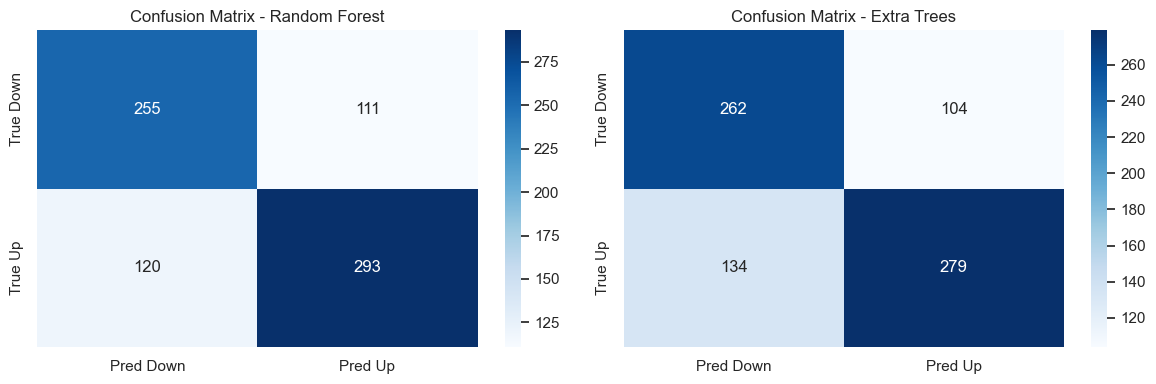

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_p, title in zip(axes,
                           [y_pred_rf, y_pred_et],
                           ['Random Forest', 'Extra Trees']):
    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Down', 'Pred Up'],
                yticklabels=['True Down', 'True Up'], ax=ax)
    ax.set_title(f'Confusion Matrix - {title}')

plt.tight_layout()
plt.show()

## 6. ROC Curves

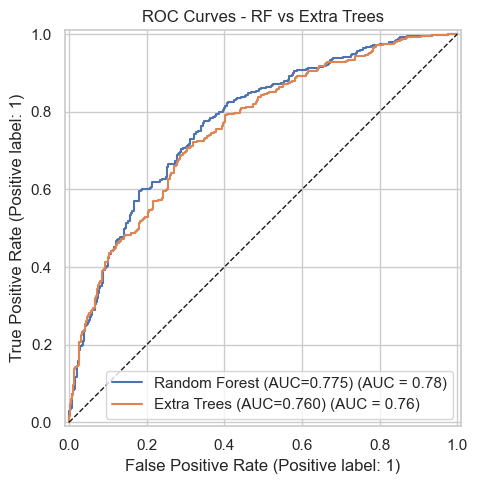

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob_rf,  ax=ax,
    name=f"Random Forest (AUC={metrics_rf['ROC-AUC']:.3f})")
RocCurveDisplay.from_predictions(
    y_test, y_prob_et, ax=ax,
    name=f"Extra Trees (AUC={metrics_et['ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title('ROC Curves - RF vs Extra Trees')
plt.tight_layout()
plt.show()

## 7. Random Forest Feature Importance

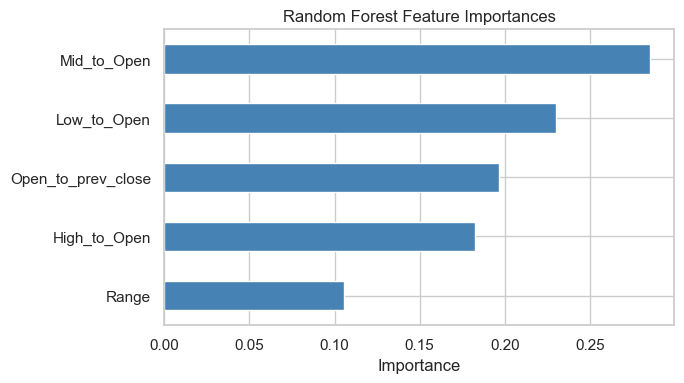

In [8]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Random Forest Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()